<a href="https://colab.research.google.com/github/werounikaa/AI_MED_Recruitment/blob/main/Recruitment_AI_MED_AGH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
#importing needed libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

## Problem Overview
The objective of this project is to build a machine learning model capable of automatically detecting hypertrophic cardiomyopathy (cardiomegaly). This is framed as a binary classification problem, where the goal is to correctly assign a patient to one of two classes:
- a healthy heart (0)
- a diseased heart (1)

To solve this problem, classical machine learning algorithms were utilized such as Logistic Regression and Random Forest.

## Dataset
The provided dataset is tabular and consists of selected geometric and imaging features extracted from patient examinations (e.g., heart and lung width, areas, structural ratios and inertia tensors).

## Data Loading and Scaling
In this section, the dataset is loaded into a Pandas DataFrame for initial inspection and preprocessing. After separating the features (X) from the target labels (y) and splitting the data into training (80%) and testing sets (20%) , feature scaling is applied.

Scaling is a crucial step, particularly for linear models like Logistic Regression, as it standardizes the range of independent variables. This ensures that features with naturally larger numeric values do not disproportionately influence the model's learning process.

In [10]:
# Importing the data from the CSV file, that contains the complete dataset that we’ll split
df = pd.read_csv('task_data.csv', decimal=',')

#separating features (X) from diagnosis (y)
y = df['Cardiomegaly']
X = df.drop(columns=['Cardiomegaly'])

#Splitting the dataset into training and testing parts (80% : 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Initialising scaller and scalling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Model 1: Logistic Regression
In this section, a Logistic Regression model is trained to serve as our baseline. This widely used linear algorithm is excellent for binary classification tasks, as it clearly shows the weight and impact of each individual feature on the final prediction.

In [11]:
#Initialising model
model_lr = LogisticRegression(random_state=42)

#Training
model_lr.fit(X_train, y_train)

#Diagnosing patients from the test set
y_pred_lr = model_lr.predict(X_test)

#Quick check of the model's predictions on a small sample
print("Predictions of diagnosis for the first 5 patients: ", y_pred_lr[:5])
print("Real diagnosis for the first 5 patients:   ", y_test[:5].values)

Predictions of diagnosis for the first 5 patients:  [0 0 1 1 1]
Real diagnosis for the first 5 patients:    [1 0 1 0 1]


## Model 2: Random Forest

In this section, we implement a Random Forest Classifier. Unlike Logistic Regression, which is a linear algorithm, Random Forest is a powerful ensemble learning method that operates by constructing a multitude of decision trees.

In [12]:
#Creating our model
model_rf = RandomForestClassifier(random_state=42)

#Training
model_rf.fit(X_train, y_train)

#Diagnosing patients from the test set
y_pred_rf = model_rf.predict(X_test)

## Cross-Validation for Both Models.

In [13]:
print("--- CROSS-VALIDATION RESULTS ---")

# Cross-validation for the Logistic Regression model
cv_scores_lr = cross_val_score(model_lr, X_train, y_train, cv=5)
print(f"\nLogistic Regression - Scores from 5 folds: {cv_scores_lr}")
print(f"Logistic Regression - Mean CV Accuracy: {cv_scores_lr.mean() * 100:.2f}%")

# Cross-validation for the Random Forest model
cv_scores_rf = cross_val_score(model_rf, X_train, y_train, cv=5)
print(f"\nRandom Forest - Scores from 5 folds: {cv_scores_rf}")
print(f"Random Forest - Mean CV Accuracy: {cv_scores_rf.mean() * 100:.2f}%")

--- CROSS-VALIDATION RESULTS ---

Logistic Regression - Scores from 5 folds: [0.83333333 0.83333333 0.83333333 0.83333333 0.8       ]
Logistic Regression - Mean CV Accuracy: 82.67%

Random Forest - Scores from 5 folds: [0.83333333 0.83333333 0.83333333 0.83333333 1.        ]
Random Forest - Mean CV Accuracy: 86.67%


###Model 1: Results and Metrics
In this section, the performance of the Logistic Regression model is evaluated using a classification report and a confusion matrix.

Accuracy of the model: 75.00%

Detailed classification report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.83      0.83      0.83         6

    accuracy                           0.75         8
   macro avg       0.67      0.67      0.67         8
weighted avg       0.75      0.75      0.75         8



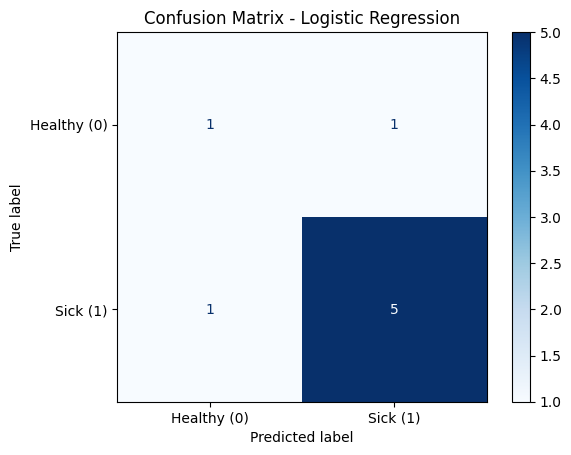

In [14]:

#Accuracy
accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy of the model: {accuracy * 100:.2f}%\n")

#Generating a detailed report
print("Detailed classification report:")
print(classification_report(y_test, y_pred_lr))

#Generating and drawing confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(
    model_lr,
    X_test,
    y_test,
    display_labels=['Healthy (0)', 'Sick (1)'],
    cmap=plt.cm.Blues
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


###Model 2: Results and Metrics
Just like previously, in this section we examine the accuracy of the Random Forest model using a classification report and a confusion matrix.

Accuracy of the Random Forest model: 62.50%

Detailed classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.71      0.83      0.77         6

    accuracy                           0.62         8
   macro avg       0.36      0.42      0.38         8
weighted avg       0.54      0.62      0.58         8



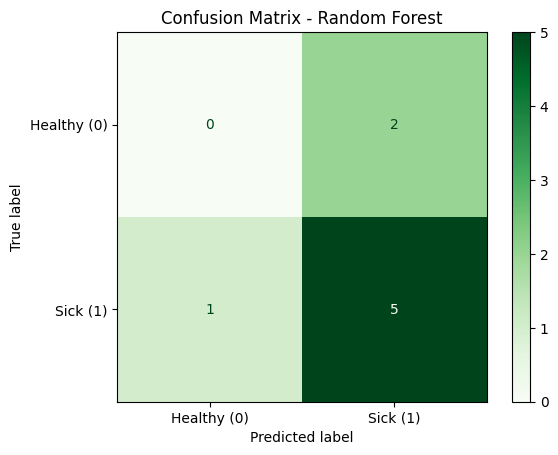

In [15]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of the Random Forest model: {accuracy_rf * 100:.2f}%\n")

print("Detailed classification report:")
print(classification_report(y_test, y_pred_rf))

disp = ConfusionMatrixDisplay.from_estimator(
    model_rf,
    X_test,
    y_test,
    display_labels=['Healthy (0)', 'Sick (1)'],
    cmap=plt.cm.Greens
)
plt.title("Confusion Matrix - Random Forest")
plt.show()

#Final results and conclusions

In [16]:
# Gathering all results into a single dictionary
summary_data = {
    'Classifier': ['Logistic Regression', 'Random Forest'],
    'Test Accuracy': ['75.00%', '62.50%'],
    'CV Accuracy (Mean)': [f"{cv_scores_lr.mean() * 100:.2f}%", f"{cv_scores_rf.mean() * 100:.2f}%"]
}

# Creating a DataFrame from the dictionary
summary_df = pd.DataFrame(summary_data)

# Styling the table: centering the text and hiding the index for better presentation
summary_df.style.set_properties(**{'text-align': 'center'}).hide(axis='index')



Classifier,Test Accuracy,CV Accuracy (Mean)
Logistic Regression,75.00%,82.67%
Random Forest,62.50%,86.67%



**1. Test Set Evaluation:**
On the isolated test set (8 patients), the **Logistic Regression** baseline outperformed the Random Forest model (75.00% vs 62.50%). The complex Random Forest struggled to generalize on this specific split, classifying all test patients as sick.

**2. The Power of Cross-Validation:**
However, applying a 5-fold Cross-Validation on the training data revealed a different story. The **Random Forest** achieved a higher mean accuracy (**86.67%**) compared to Logistic Regression (**82.67%**).


This discrepancy perfectly demonstrates variance in small datasets. A single train-test split (even with a fixed random state) can be heavily biased. While Logistic Regression is simpler and more interpretable, the Cross-Validation proves that Random Forest is actually slightly more robust across different data permutations. To build a truly reliable clinical tool, acquiring a significantly larger dataset is the necessary next step.